# Este notebook descarga el dataset de cartas desde kaggle

Recordar mover el archivo kaggle.json dentro de la carpeta .kaggle en tu ordenador. Busca esa ruta

El archivo kaggle.json contiene la key y el usuario de kaggle para acceder al API

In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import glob # trabajar con rutas de archivos
import random # elementos aleatorios
import cv2 # procesamiento de imágenes
import matplotlib.pyplot as plt # visualización de datos
import pandas as pd # manipulacion y analisis de datos estructurados 
import numpy as np # calculos numericos
from PIL import Image # para la manipulación de imágenes
import seaborn as sns # Graficas y tablas

Descargar el DataSet

In [ ]:
# Inicializar API
api = KaggleApi()
api.authenticate()

# Descargar dataset
dataset_name = "archanghosh/yugioh-database"  # se busca el nombre del dataset en la página de kaggle
api.dataset_download_files(dataset_name, path="yugioh_dataset", unzip=True)


Dataset URL: https://www.kaggle.com/datasets/archanghosh/yugioh-database


Realizar Análisis Exploratirio

In [ ]:
# Carga el archivo CSV en un DataFrame
data = pd.read_csv('yugioh_dataset/Yugi_db_cleaned.csv')

# Carga de imagenes de forma aleatoria
data_images = glob.glob('yugioh_dataset/Yugi_images/*.png')
random_sample_images = random.sample(data_images, 10)
random_test_images = []
for img_path in random_sample_images:
    with Image.open(img_path) as img:
        img = img.convert("RGB")  # Convierte la imagen a RGB
        img_np = np.array(img)  # Convierte la imagen a un array de NumPy
        random_test_images.append(img_np)  # Añade la imagen al array

Ver las imágenes de las cartas

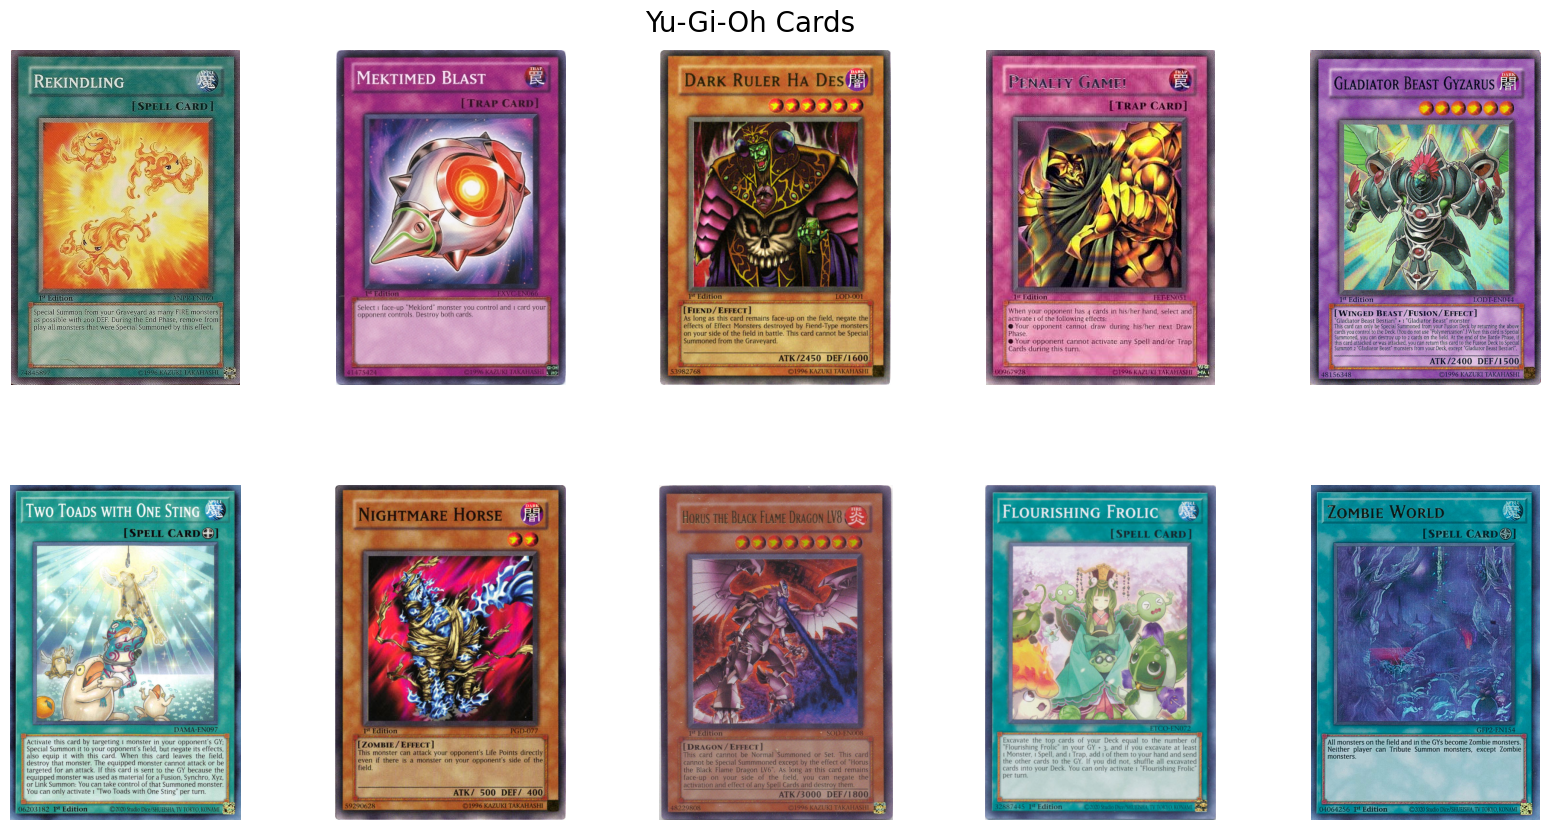

In [ ]:
# link al dataset para ver el resto del código: https://www.kaggle.com/datasets/archanghosh/yugioh-database/data
# Mostrar las imágenes
plt.figure(figsize=(20, 10))
columns = 5
rows = 2

for i, image in enumerate(random_test_images):
    ax = plt.subplot(rows, columns, i + 1)
    ax.axis("off")
    plt.imshow(image)

plt.suptitle("Yu-Gi-Oh Cards", fontsize=20, y=0.92)
plt.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()  # Muestra la figura

Analizar nulos y datos faltantes

In [ ]:
# Revisar los datos faltantes y calcular el porcentaje respecto al total
missing_data = data.isnull().sum()
total_data = len(data)
missing_percentage = (missing_data / total_data) * 100

# Mostrar la cantidad de valores nulos y su porcentaje
print("Cantidad de valores nulos por columna:")
print(missing_data)
print("\nPorcentaje de valores nulos por columna:")
print(missing_percentage)

Cantidad de valores nulos por columna:
Image_name                      0
Card-set                        0
Card_number                     0
Rarity                          0
Card_name                       0
Other names                  8214
Card type                       0
Attribute                    3034
Types                        3034
Level                        3568
ATK / DEF                    3261
Password                        1
Status                          0
Effect types                  387
Ritual required              8324
Property                     5339
Ritual Monster required      8343
Pendulum Scale               8162
Rank                         8066
Link Arrows                  8146
ATK / LINK                   8146
Other names (Japanese)       8368
Summoned by the effect of    8371
dtype: int64

Porcentaje de valores nulos por columna:
Image_name                    0.000000
Card-set                      0.000000
Card_number                   0.000000
Rarity 

In [ ]:
data['Image_name']

0            MRD-116 R.png
1         PHSW-EN014 C.png
2        ROTD-EN030 UR.png
3            PGD-093 R.png
4         RIRA-EN060 C.png
               ...        
8368      TDIL-EN004 C.png
8369      LODT-EN039 R.png
8370    DAMA-EN066 ScR.png
8371    MACR-EN079 ScR.png
8372      TSHD-EN008 R.png
Name: Image_name, Length: 8373, dtype: object